# Assignment 4 — CIFAR-10 ConvNet

**DATAX504** · Due end of Week 8

Build on **Chapter 8** (ConvNets, augmentation) and ideas from **Chapters 9–10** (interpretation). You design the stack; the goal is a working pipeline you can explain, not a copy of a tutorial.

## Tasks
1. Load CIFAR-10, normalise, create a train / validation split
2. Build a **data augmentation** pipeline used during training
3. Train a **ConvNet** that reaches **>65%** test accuracy
4. Visualise at least one filter / feature (layer weights or activation-based)
5. Brief interpretation of what that filter responds to (Moodle `a4_interpretation`)

## Moodle fields
`a4_repo`, `a4_test_acc`, `a4_filter_layer`, `a4_interpretation`

## AI disclosure (required)
Fill the table in the next cell before you submit.


## AI disclosure

| Field | Your answer |
|-------|-------------|
| Tool / model | OpenAI, GPT-5.6 Sol |
| Used for | Explaining code, debugging, and reviewing related ConvNet concepts.|
| Verified how | Ran all cells, checked the outputs and accuracy, and visualisations.|
| Not used for | Inventing accuracy values, replacing the execution and verification of the notebook, or directly generating written conclusions.|


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers

import random
import numpy as np
import tensorflow as tf

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

## 1. Load & prepare CIFAR-10

Hints:
- `keras.datasets.cifar10.load_data()`
- cast pixels to float and scale to `[0, 1]` (or another range you document)
- flatten label shape if needed (`y.ravel()`)
- hold out a validation slice from the training set (e.g. last 5_000 or 10_000)


In [2]:
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()


# Normalise pixel values from 0-255 to 0-1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten labels from (n, 1) to (n,)
y_train = y_train.ravel()
y_test = y_test.ravel()

# Use the last 5,000 training samples as validation data
x_val = x_train[-5000:]
y_val = y_train[-5000:]

# Keep the remaining 45,000 samples for training
x_train = x_train[:-5000]
y_train = y_train[:-5000]

print("train:", x_train.shape, y_train.shape)
print("val:  ", x_val.shape, y_val.shape)
print("test: ", x_test.shape, y_test.shape)


train: (45000, 32, 32, 3) (45000,)
val:   (5000, 32, 32, 3) (5000,)
test:  (10000, 32, 32, 3) (10000,)


## 2. Data augmentation

Build a small `keras.Sequential` of image layers (e.g. flip / rotation / zoom).
Apply it **inside** the model (or as a preprocessing layer) so training sees augmented batches.

Preview a few transforms on one training image to check it works.


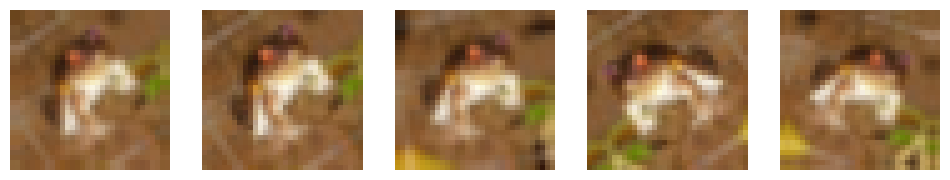

In [3]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ],
    name="augmentation",
)

# TODO: preview — take one image from x_train, run it through data_augmentation a few times, plot
sample = x_train[0]

fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for i in range(5):
    augmented = data_augmentation(
        np.expand_dims(sample, axis=0),
        training=True
    )[0]

    axes[i].imshow(augmented)
    axes[i].axis("off")

plt.show()


## 3. ConvNet model

Requirements:
- Input shape `(32, 32, 3)`
- Include your augmentation as the first stage of the graph (training only behaviour is fine)
- At least two `Conv2D` + pooling stages, then a dense classifier for 10 classes
- Name at least one early conv layer (you will need the name for visualisation)

Compile with a suitable loss for integer class labels (or one-hot — be consistent).


In [5]:
inputs = keras.Input(shape=(32, 32, 3))

x = data_augmentation(inputs)

x = layers.Conv2D(
    32, 3,
    padding="same",
    activation="relu",
    name="conv2d_1"
)(x)
x = layers.MaxPooling2D(2)(x)

x = layers.Conv2D(
    64, 3,
    padding="same",
    activation="relu"
)(x)
x = layers.MaxPooling2D(2)(x)

x = layers.Conv2D(
    128, 3,
    padding="same",
    activation="relu"
)(x)
x = layers.MaxPooling2D(2)(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(10, activation="softmax")(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

print("Model ready:", model is not None)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,538 (369.29 KB)

 Trainable params: 94,538 (369.29 KB)

 Non-trainable params: 0 (0.00 B)

Model ready: True


## 4. Train & evaluate

Fit with `validation_data`. Aim for **>65%** test accuracy (Moodle wants the percentage).
Plot train vs val accuracy if useful for your write-up.


In [6]:
# Stop training if validation accuracy stops improving
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=8,
    restore_best_weights=True,
)

# Train the ConvNet
history = model.fit(
    x_train,
    y_train,
    epochs=30,
    batch_size=128,
    validation_data=(x_val, y_val),
    callbacks=[early_stop],
    verbose=1,
)

# Evaluate once on the test set
test_loss, test_acc = model.evaluate(
    x_test,
    y_test,
    verbose=0,
)

print(
    f"Test accuracy % (Moodle a4_test_acc): {100 * test_acc:.2f}"
)

Epoch 1/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.2647 - loss: 1.9590 - val_accuracy: 0.3684 - val_loss: 1.7513
Epoch 2/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.3716 - loss: 1.7126 - val_accuracy: 0.4176 - val_loss: 1.6049
Epoch 3/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.4148 - loss: 1.6103 - val_accuracy: 0.4490 - val_loss: 1.5539
Epoch 4/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.4442 - loss: 1.5390 - val_accuracy: 0.4678 - val_loss: 1.4547
Epoch 5/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.4599 - loss: 1.4939 - val_accuracy: 0.4856 - val_loss: 1.4247
Epoch 6/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.4745 - loss: 1.4566 - val_accuracy: 0.4960 - val_loss: 1.4392
Epoch 7/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.4875 - loss: 1.4209 - val_accuracy: 0.5098 - val_loss: 1.3524
Epoch 8/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.4983 - loss: 1.3943 - val_accu

## 5. Filter visualisation

Pick a named conv layer (`a4_filter_layer`). Minimum expectation: plot first-layer filter weights as small images.

Optional deeper approach: gradient ascent / activation maximisation for one filter index (Ch 10 style).


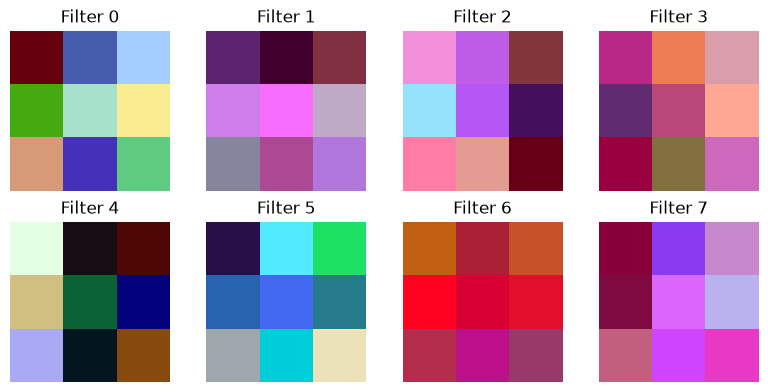

Visualisation layer (Moodle a4_filter_layer): conv2d_1


In [7]:
VIS_LAYER = "conv2d_1"  # TODO: match the name you set — Moodle a4_filter_layer

conv_layer = model.get_layer(VIS_LAYER)

# Extract filter weights and biases
filters, biases = conv_layer.get_weights()

# Plot the first 8 filters
fig, axes = plt.subplots(2, 4, figsize=(8, 4))

for i, ax in enumerate(axes.flat):
    f = filters[:, :, :, i]

    # Normalise for display
    f_min, f_max = f.min(), f.max()
    f = (f - f_min) / (f_max - f_min + 1e-8)

    ax.imshow(f)
    ax.set_title(f"Filter {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

print(f"Visualisation layer (Moodle a4_filter_layer): {VIS_LAYER}")


## 6. Interpretation (Moodle `a4_interpretation`)

Max ~200 words: what pattern does your chosen filter respond to?


*Your interpretation here.*

I visualised filters from the first convolutional layer, conv2d_1. The filters show different colour combinations and changes across their small 3×3 areas.

For example, some filters contain clear differences between bright and dark regions or between different colour channels. This suggests that the first convolutional layer is learning simple visual features such as colour contrast, edges, and small local patterns.

These features are still quite basic, which makes sense for an early ConvNet layer. Later layers can combine these simpler patterns into more complex features that help the model distinguish between the CIFAR-10 classes.

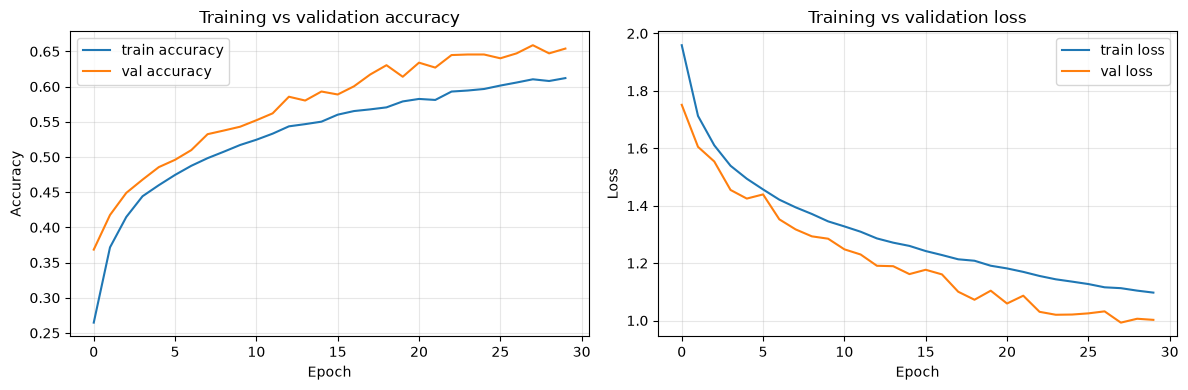

In [11]:
# Plot training and validation curves

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
axes[0].plot(history.history["accuracy"], label="train accuracy")
axes[0].plot(history.history["val_accuracy"], label="val accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Training vs validation accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history["loss"], label="train loss")
axes[1].plot(history.history["val_loss"], label="val loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Training vs validation loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()